# Fase 2 — Curriculum Learning: Mans → Partides

**Objectiu:** Investigar si entrenar primer en mans aïllades i després fer finetune en partides completes (curriculum learning) millora el rendiment dels agents respecte entrenar directament en partides.

**Disseny experimental:**
- **Grup control**: 4 agents × 24M steps en partides, sense self-play
- **Curriculum**: 4 agents × 12M mans + 12M partides (finetune)
- Tots els agents: 10% Random + 90% AgentRegles (sense self-play, oponent estandarditzat)

---

## 1. Context teòric

### 1.1 Curriculum Learning

El **curriculum learning** és una estratègia d'entrenament on l'agent s'exposa primer a tasques més simples i progressivament a tasques més complexes. Inspirat en com els humans aprenen (des de conceptes bàsics cap a abstraccions), ha demostrat accelerar la convergència en molts dominis de RL.

En el context del Truc:
- **Mans aïllades**: cada episodi = una mà (3 cartes, ~3-9 decisions). Recompensa immediata al final de la mà.
- **Partides completes**: cada episodi = partida fins a 24 punts (~5-15 mans). Recompensa esparsa (al final de la partida).

La hipòtesi és que aprendre primer les heurístiques bàsiques del joc de cartes (quina carta jugar, quan apostar al truc) facilita l'aprenentatge posterior de la gestió estratègica a llarg termini.

---

### 1.2 Consistència de recompenses entre fases

Ambdós entorns (`TrucGymEnv` i `TrucGymEnvMa`) utilitzen la mateixa estructura de recompenses:
- **Rewards intermedis**: ±(pts_truc + pts_envit) / 24 × 5.0 → escala similar en ambdós entorns
- **Reward final**: +1 (guanya la mà/partida) / -1 (perd) → escala idèntica

Aquesta coherència garanteix que els pesos apresos en mans siguin reutilitzables directament en partides sense necessitat d'ajustar escales.

---

### 1.3 Riscos del curriculum

| Risc | Descripció | Agent més afectat |
|---|---|---|
| **Distribució shift** | Estratègia òptima en mans ≠ estratègia òptima en partides | Tots |
| **Oblit catastròfic** | El finetune sobreescriu el coneixement previ | PPO (on-policy) |
| **Sobreajust a mans** | L'agent aprèn heurístiques que no generalitzen | DQN RLCard, NFSP |

**PPO** és el més vulnerable a l'oblit catastròfic perquè és on-policy: cada actualització descarta completament les dades anteriors. Quan es passa de mans a partides, totes les trajectòries del buffer (de mans) s'abandonant immediatament. Per als agents off-policy (DQN, NFSP), el replay buffer es reinicia intencionadament per evitar contaminació cross-distribució.

---

## 2. Setup

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

AGENTS   = ['dqn_rlcard', 'nfsp_rlcard', 'dqn_sb3', 'ppo_sb3']
COLORS   = {'dqn_rlcard': '#e74c3c', 'nfsp_rlcard': '#3498db',
            'dqn_sb3': '#2ecc71', 'ppo_sb3': '#9b59b6'}
LABELS   = {'dqn_rlcard': 'DQN RLCard', 'nfsp_rlcard': 'NFSP RLCard',
            'dqn_sb3': 'DQN SB3', 'ppo_sb3': 'PPO SB3'}

BASE = Path('../../..')  # arrel del projecte

def suavitzar(series: pd.Series, window: int) -> pd.Series:
    return series.rolling(window=window, center=True, min_periods=1).mean()

def trobar_ultima_carpeta(patro: str) -> Path | None:
    carpetes = sorted(glob.glob(str(BASE / patro)), key=os.path.getmtime)
    return Path(carpetes[-1]) if carpetes else None

def carregar_logs(carpeta_base: Path, log_name: str = 'training_log.csv') -> dict:
    """Carrega els CSVs de cada agent des d'una carpeta d'experiment."""
    dades = {}
    for agent in AGENTS:
        path = carpeta_base / agent / log_name
        if path.exists():
            dades[agent] = pd.read_csv(path)
    return dades

print('Setup completat.')
print(f'Directori base: {BASE.resolve()}')


Setup completat.
Directori base: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc


---

## 3. Grup Control — 24M steps en partides (sense self-play)

In [3]:
carpeta_control = trobar_ultima_carpeta(
    'TFG_Doc/notebooks/2_curriculum_learning/resultats_fase2_control_*'
)

if carpeta_control is None:
    print('No s\'ha trobat cap carpeta de resultats del grup control')
    dades_control = {}
else:
    print(f'Carpeta control: {carpeta_control.name}')
    dades_control = carregar_logs(carpeta_control, 'training_log.csv')
    for agent, df in dades_control.items():
        print(f'  {LABELS[agent]}: {len(df)} avaluacions, '
              f'max step={df["step"].max():,}, '
              f'millor metric={df["eval_metric"].max():.1f}%')


Carpeta control: resultats_fase2_control_11_04_1145h
  DQN RLCard: 48 avaluacions, max step=24,000,020, millor metric=52.0%
  NFSP RLCard: 48 avaluacions, max step=24,000,026, millor metric=55.5%
  DQN SB3: 48 avaluacions, max step=24,000,000, millor metric=60.5%
  PPO SB3: 48 avaluacions, max step=24,000,768, millor metric=35.0%


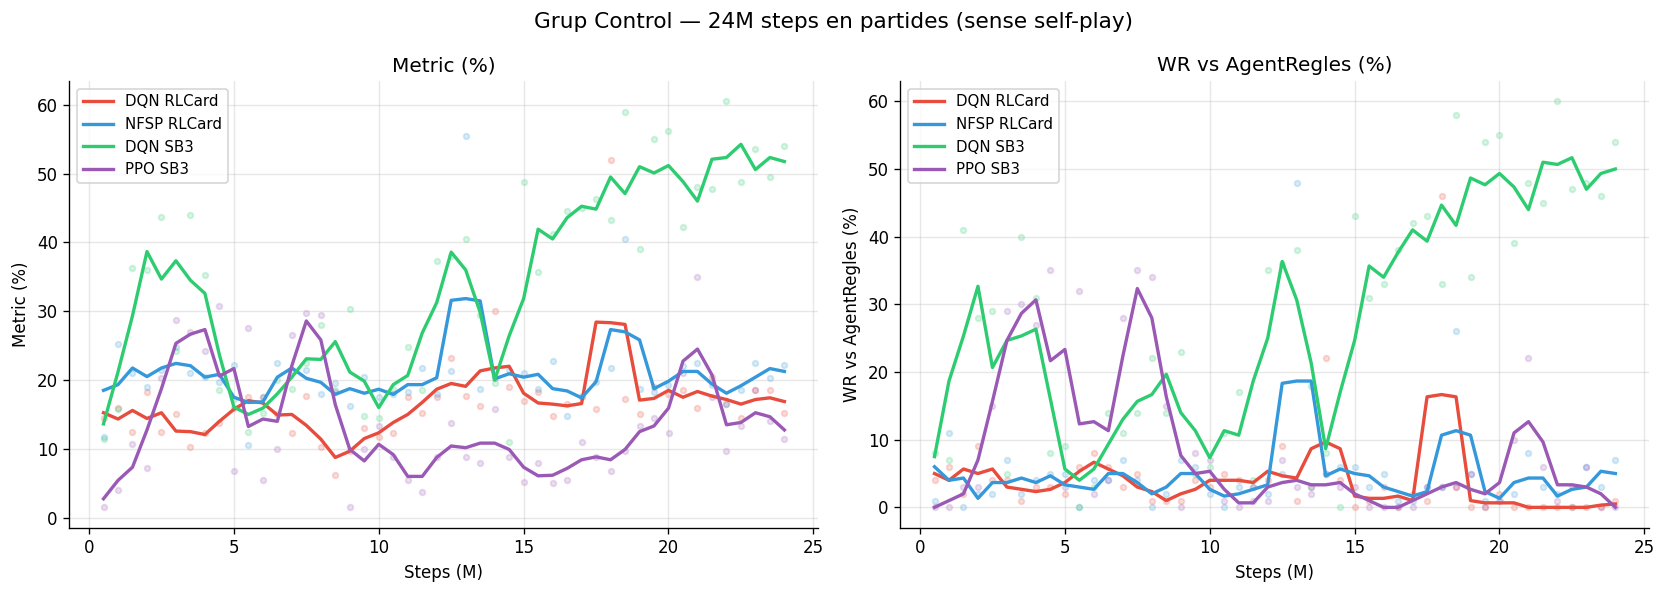

In [5]:
if dades_control:
    WINDOW = 3
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Grup Control — 24M steps en partides (sense self-play)', fontsize=13)

    for agent, df in dades_control.items():
        col = COLORS[agent]
        lbl = LABELS[agent]
        s   = df['step'] / 1e6

        for ax, col_y, titol in zip(axes,
                                    ['eval_metric', 'eval_wr_regles'],
                                    ['Metric (0.25×WR_rand + 0.75×WR_regles)', 'WR vs AgentRegles (%)']):
            ax.scatter(s, df[col_y], color=col, alpha=0.2, s=12)
            ax.plot(s, suavitzar(df[col_y], WINDOW), color=col, label=lbl, linewidth=2)

    for ax, titol in zip(axes, ['Metric (%)', 'WR vs AgentRegles (%)']):
        ax.set_xlabel('Steps (M)')
        ax.set_ylabel(titol)
        ax.set_title(titol)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print('Sense dades. Executa el grup control primer.')


In [6]:
if dades_control:
    files = {}
    for agent in AGENTS:
        resum = carpeta_control / 'resum_control.txt'
        elapsed = None
        if resum.exists():
            for line in resum.read_text().splitlines():
                if agent.replace('_', '') in line.replace('_', '').lower() or \
                   LABELS[agent].lower().replace(' ', '') in line.lower().replace(' ', ''):
                    try:
                        elapsed = int(line.split(':')[1].split('s')[0].strip())
                    except Exception:
                        pass

        if agent in dades_control:
            df = dades_control[agent]
            files[agent] = {
                'Agent': LABELS[agent],
                'Millor metric (%)': f"{df['eval_metric'].max():.1f}",
                'Metric final (%)': f"{df['eval_metric'].iloc[-1]:.1f}",
                'Millor WR Regles (%)': f"{df['eval_wr_regles'].max():.1f}",
                'Steps completats': f"{df['step'].max()/1e6:.1f}M",
                'Temps (s)': elapsed or '—',
            }

    if files:
        pd.DataFrame(files.values()).set_index('Agent')


---

## 4. Curriculum Learning — 12M mans + 12M partides

In [4]:
carpeta_curr = trobar_ultima_carpeta(
    'TFG_Doc/notebooks/2_curriculum_learning/resultats_fase2_curriculum_*'
)

if carpeta_curr is None:
    print('⚠ No s\'ha trobat cap carpeta de resultats del curriculum.')
    print('  Executa: bash RL/entrenament/entrenamentsComparatius/fase2/run_fase2_curriculum.sh')
    dades_mans = {}
    dades_partides = {}
else:
    print(f'Carpeta curriculum: {carpeta_curr.name}')
    dades_mans     = carregar_logs(carpeta_curr, 'training_log_mans.csv')
    dades_partides = carregar_logs(carpeta_curr, 'training_log_partides.csv')
    for agent in AGENTS:
        if agent in dades_mans and agent in dades_partides:
            dm = dades_mans[agent]
            dp = dades_partides[agent]
            print(f'  {LABELS[agent]}:')
            print(f'    Mans:     {len(dm)} aval, max metric={dm["eval_metric"].max():.1f}%')
            print(f'    Partides: {len(dp)} aval, max metric={dp["eval_metric"].max():.1f}%')


Carpeta curriculum: resultats_fase2_curriculum_13_04_0947h
  DQN RLCard:
    Mans:     24 aval, max metric=26.0%
    Partides: 24 aval, max metric=22.2%
  NFSP RLCard:
    Mans:     24 aval, max metric=27.2%
    Partides: 24 aval, max metric=60.0%
  DQN SB3:
    Mans:     24 aval, max metric=86.2%
    Partides: 24 aval, max metric=56.0%
  PPO SB3:
    Mans:     24 aval, max metric=87.2%
    Partides: 24 aval, max metric=75.0%


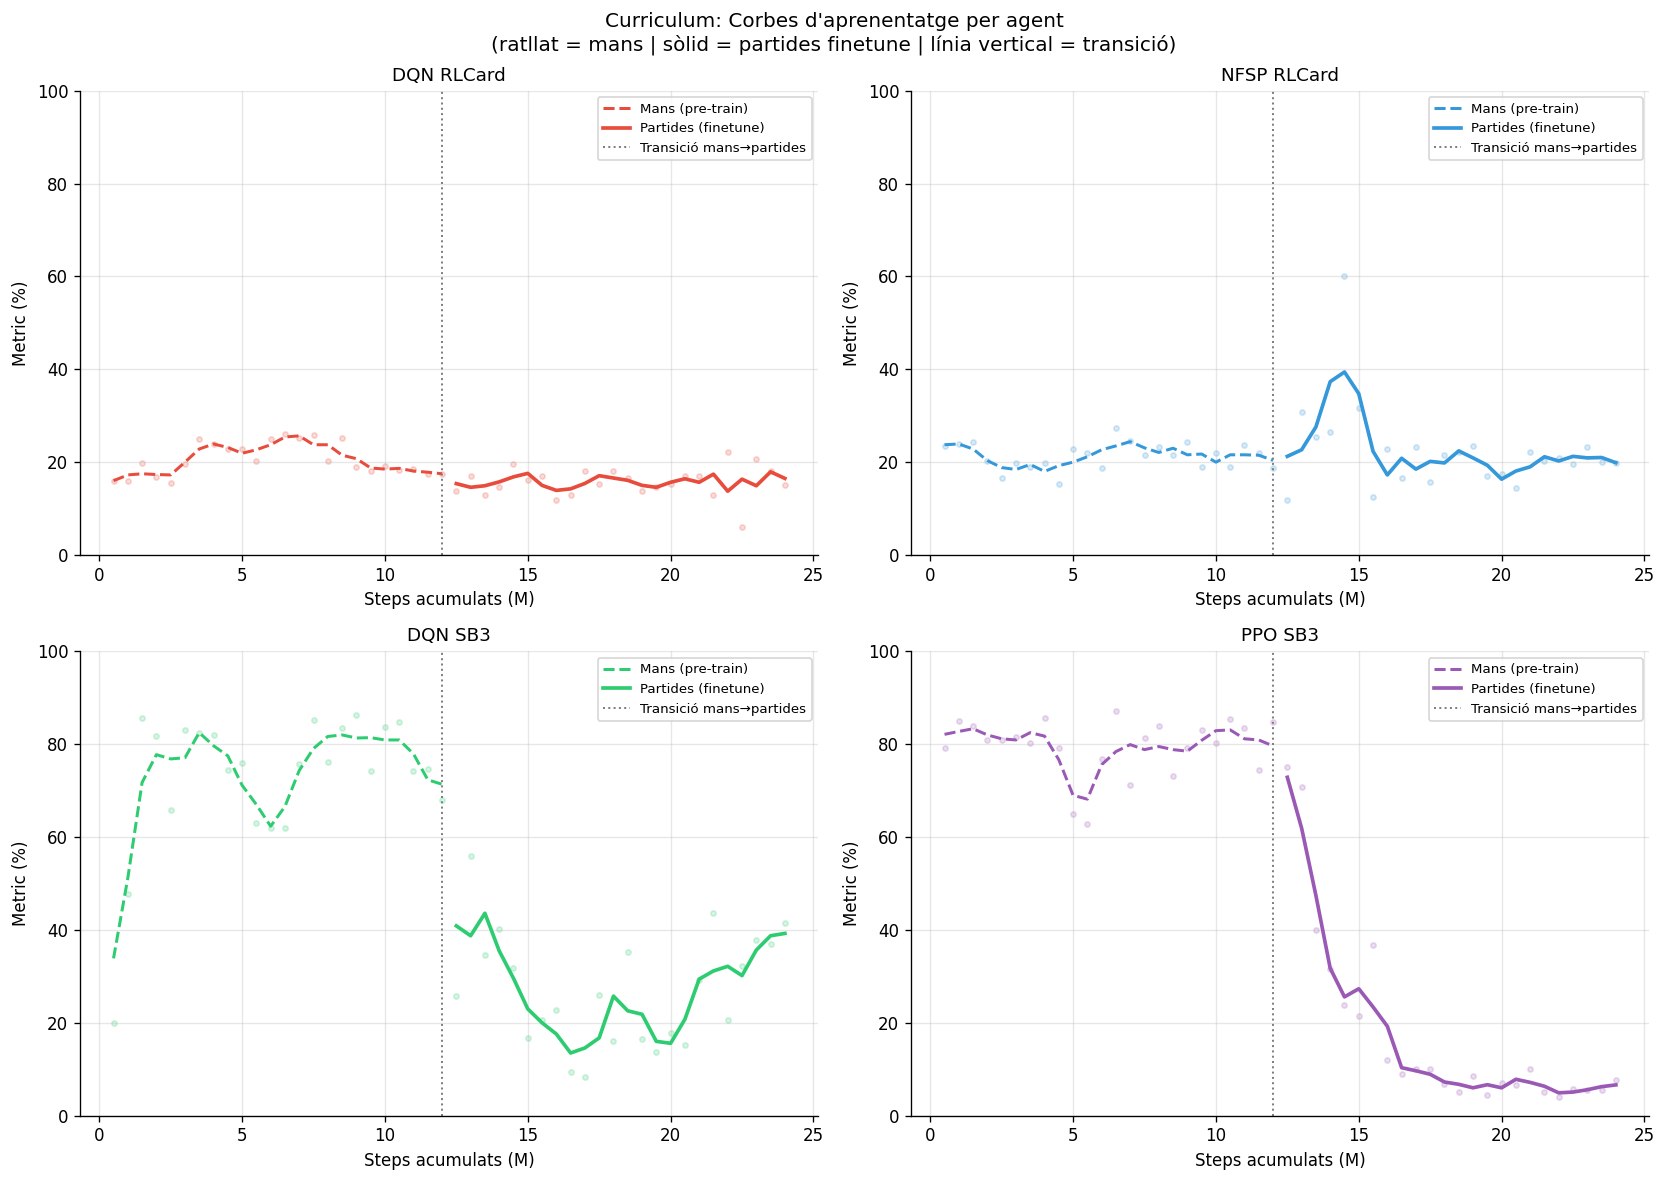

In [7]:
if dades_mans or dades_partides:
    WINDOW_MANS     = 3
    WINDOW_PARTIDES = 3

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Curriculum: Corbes d\'aprenentatge per agent\n'
                 '(ratllat = mans | sòlid = partides finetune | línia vertical = transició)',
                 fontsize=12)

    for ax, agent in zip(axes.flat, AGENTS):
        col = COLORS[agent]
        dm  = dades_mans.get(agent)
        dp  = dades_partides.get(agent)

        mans_max_step = 0
        if dm is not None and len(dm) > 0:
            s = dm['step'] / 1e6
            ax.scatter(s, dm['eval_metric'], color=col, alpha=0.2, s=10)
            ax.plot(s, suavitzar(dm['eval_metric'], WINDOW_MANS),
                    color=col, linestyle='--', linewidth=1.8, label='Mans (pre-train)')
            mans_max_step = dm['step'].max() / 1e6

        if dp is not None and len(dp) > 0:
            # step del finetune en coordenades acumulades (12M + step_parcial)
            s_offset = dp['step'] / 1e6 + mans_max_step
            ax.scatter(s_offset, dp['eval_metric'], color=col, alpha=0.2, s=10)
            ax.plot(s_offset, suavitzar(dp['eval_metric'], WINDOW_PARTIDES),
                    color=col, linestyle='-', linewidth=2.2, label='Partides (finetune)')

        if mans_max_step > 0:
            ax.axvline(mans_max_step, color='gray', linestyle=':', linewidth=1.2,
                       label='Transició mans→partides')

        ax.set_title(LABELS[agent], fontsize=11)
        ax.set_xlabel('Steps acumulats (M)')
        ax.set_ylabel('Metric (%)')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()
else:
    print('Sense dades de curriculum. Executa el script primer.')


---

## 5. Comparació: Control vs Curriculum

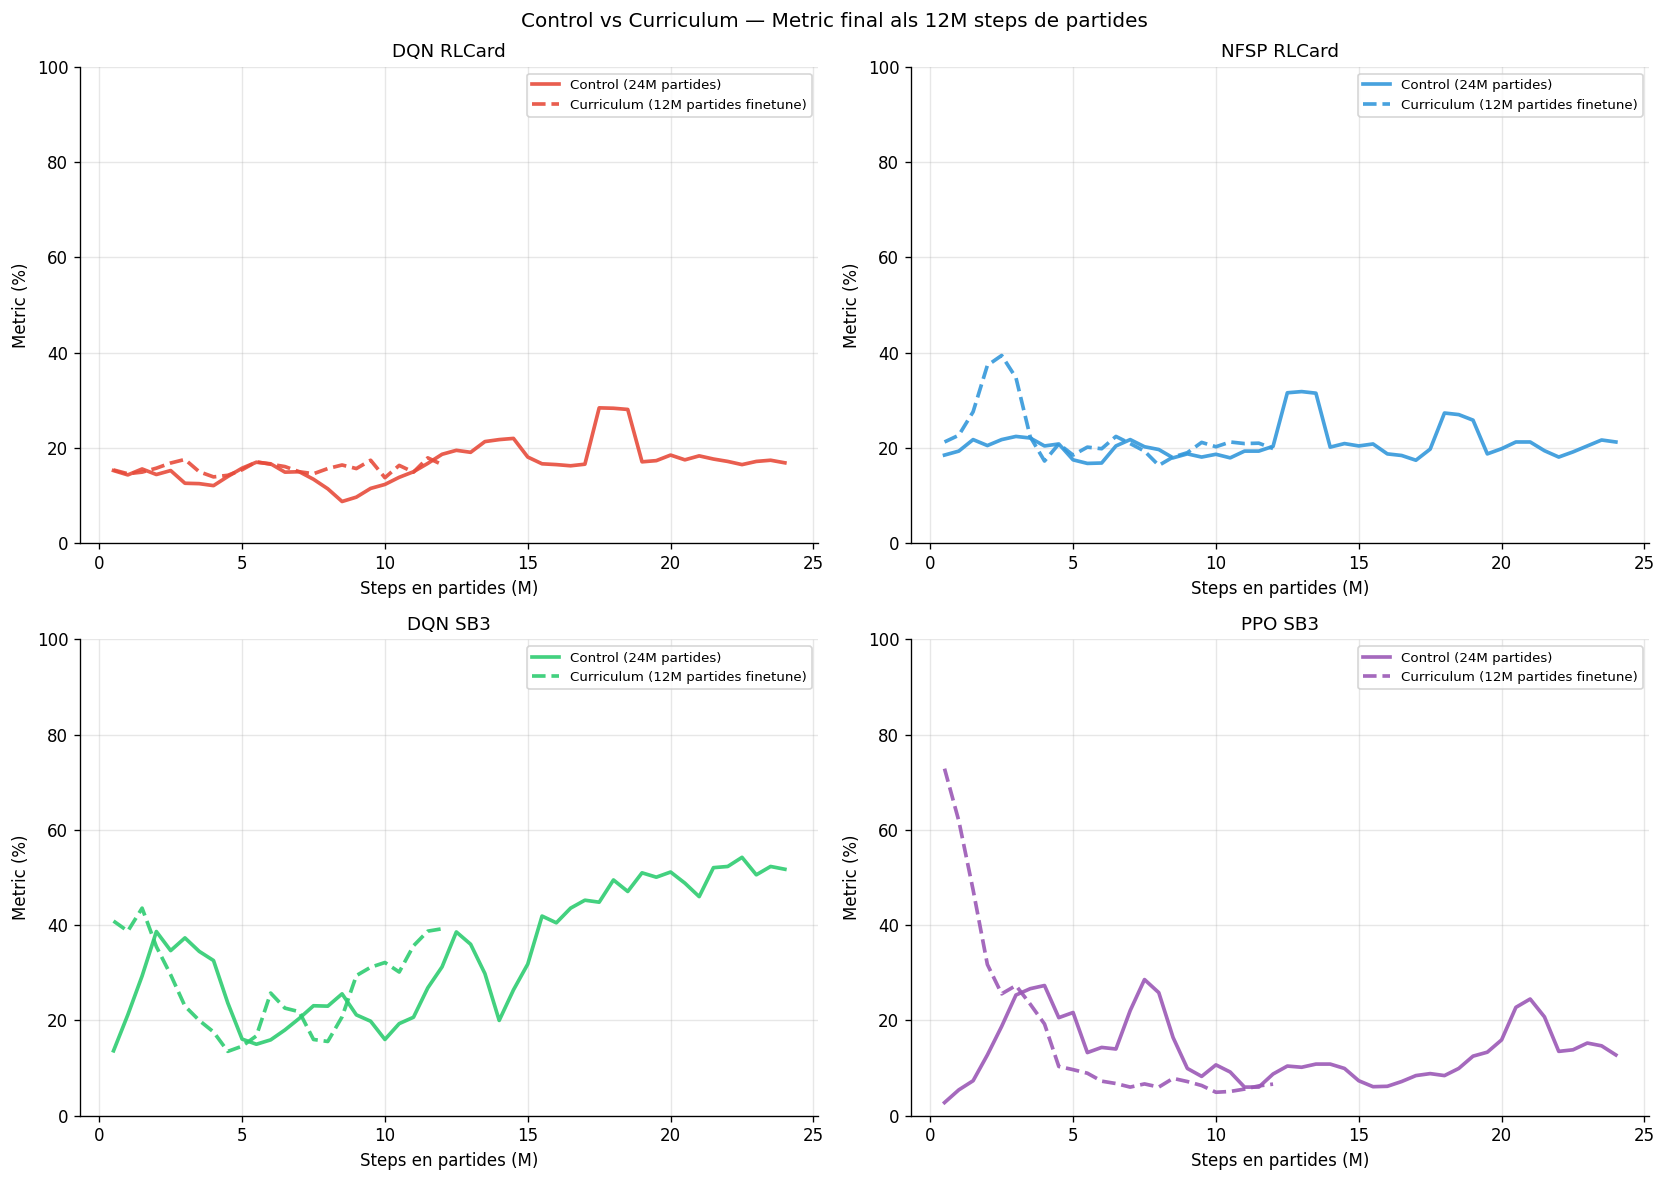

In [8]:
if dades_control and dades_partides:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Control vs Curriculum — Metric final als 12M steps de partides',
                 fontsize=12)

    for ax, agent in zip(axes.flat, AGENTS):
        col = COLORS[agent]

        dc = dades_control.get(agent)
        dp = dades_partides.get(agent)

        if dc is not None:
            s = dc['step'] / 1e6
            ax.plot(s, suavitzar(dc['eval_metric'], 3),
                    color=col, linestyle='-', linewidth=2.2,
                    label='Control (24M partides)', alpha=0.9)

        if dp is not None:
            # step del finetune: comparar a partir del punt equivalent (12M steps de partides)
            s = dp['step'] / 1e6
            ax.plot(s, suavitzar(dp['eval_metric'], 3),
                    color=col, linestyle='--', linewidth=2.2,
                    label='Curriculum (12M partides finetune)', alpha=0.9)

        ax.set_title(LABELS[agent], fontsize=11)
        ax.set_xlabel('Steps en partides (M)')
        ax.set_ylabel('Metric (%)')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()
elif not dades_control:
    print('Falten dades del grup control.')
elif not dades_partides:
    print('Falten dades del curriculum.')


### 5.1 Etapa 1 equivalent — 12M mans vs primers 12M partides

A la comparació anterior es mostra el control sencer (24M) contra el finetune del curriculum (12M partides partint de pesos pre-entrenats). La pregunta complementària és: **amb el mateix pressupost de 12M steps, aprèn més entrenant sobre mans que directament sobre partides?**

Les dues corbes que es comparen a continuació són:
- **Control (primers 12M partides)**: l'agent comença des de zero i entrena 12M steps en partides senceres.
- **Curriculum etapa 1 (12M mans)**: l'agent comença des de zero i entrena 12M steps en mans aïllades.

Totes dues s'**avaluen sobre partides senceres** (`ENV_CONFIG`), per tant és una comparació directa i just del valor instrumental de cada règim d'entrenament per al rendiment final desitjat.

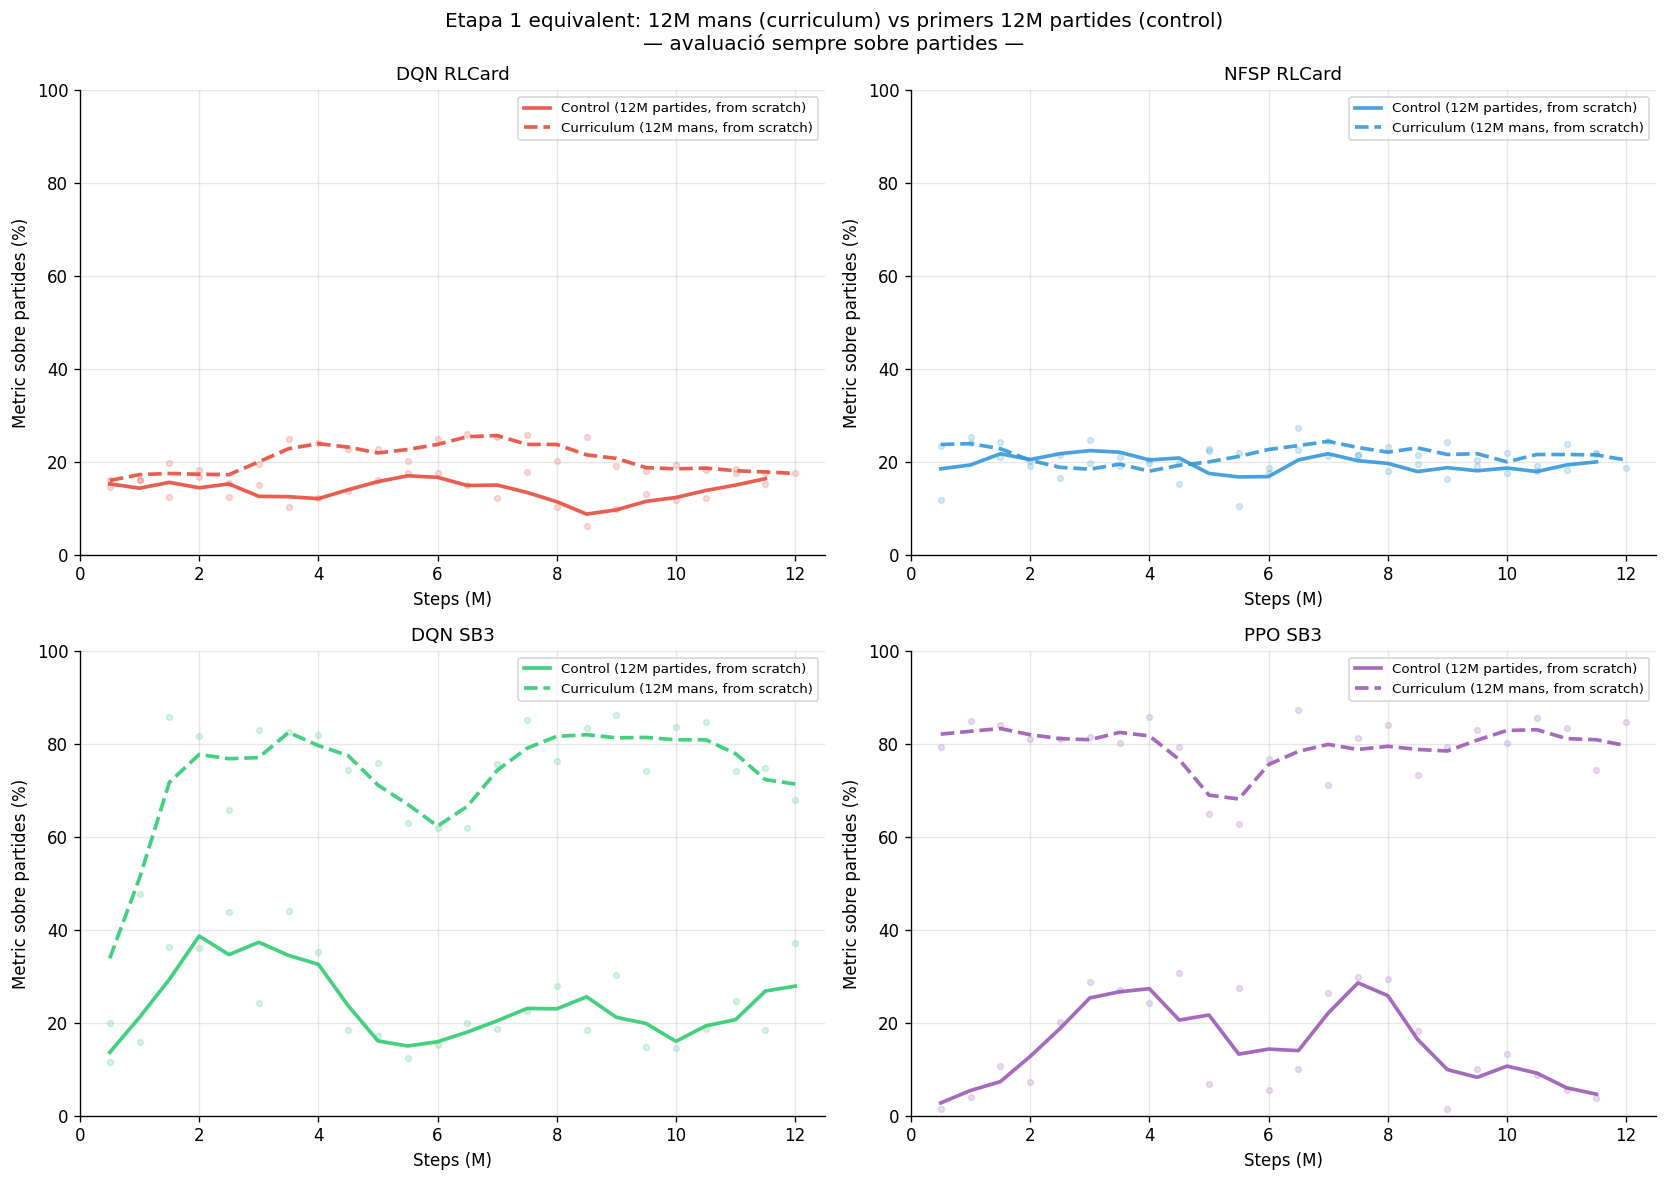

Pic de la mètrica als primers 12M steps:
  Agent              Control 12M     Mans 12M    Δ (mans-ctrl)
  DQN RLCard               18.2%        26.0% +           7.8 pp
  NFSP RLCard              25.2%        27.2% +           2.0 pp
  DQN SB3                  44.0%        86.2% +          42.2 pp
  PPO SB3                  30.8%        87.2% +          56.5 pp


In [11]:
if dades_control and dades_mans:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Etapa 1 equivalent: 12M mans (curriculum) vs primers 12M partides (control)\n'
                 '— avaluació sempre sobre partides —',
                 fontsize=12)

    for ax, agent in zip(axes.flat, AGENTS):
        col = COLORS[agent]
        dc = dades_control.get(agent)
        dm = dades_mans.get(agent)

        if dc is not None:
            dc_12m = dc[dc['step'] <= 12_000_000]
            s = dc_12m['step'] / 1e6
            ax.scatter(s, dc_12m['eval_metric'], color=col, alpha=0.2, s=12)
            ax.plot(s, suavitzar(dc_12m['eval_metric'], 3),
                    color=col, linestyle='-', linewidth=2.2,
                    label='Control (12M partides, from scratch)', alpha=0.9)

        if dm is not None:
            s = dm['step'] / 1e6
            ax.scatter(s, dm['eval_metric'], color=col, alpha=0.2, s=12)
            ax.plot(s, suavitzar(dm['eval_metric'], 3),
                    color=col, linestyle='--', linewidth=2.2,
                    label='Curriculum (12M mans, from scratch)', alpha=0.9)

        ax.set_title(LABELS[agent], fontsize=11)
        ax.set_xlabel('Steps (M)')
        ax.set_ylabel('Metric sobre partides (%)')
        ax.legend(fontsize=8, loc='best')
        ax.set_ylim(0, 100)
        ax.set_xlim(0, 12.5)

    plt.tight_layout()
    plt.show()

    print('Pic de la mètrica als primers 12M steps:')
    print(f'  {"Agent":<15} {"Control 12M":>14} {"Mans 12M":>12} {"Δ (mans-ctrl)":>16}')
    for agent in AGENTS:
        dc = dades_control.get(agent)
        dm = dades_mans.get(agent)
        if dc is None or dm is None:
            continue
        dc_12m = dc[dc['step'] <= 12_000_000]
        ctrl_best = dc_12m['eval_metric'].max()
        mans_best = dm['eval_metric'].max()
        delta = mans_best - ctrl_best
        sign = '+' if delta >= 0 else ''
        print(f'  {LABELS[agent]:<15} {ctrl_best:>13.1f}% {mans_best:>11.1f}% {sign}{delta:>14.1f} pp')
elif not dades_control:
    print('Falten dades del grup control.')
elif not dades_mans:
    print('Falten dades de les mans.')

In [9]:
if dades_control and dades_partides:
    rows = []
    for agent in AGENTS:
        dc = dades_control.get(agent)
        dm = dades_mans.get(agent)
        dp = dades_partides.get(agent)

        ctrl_best  = dc['eval_metric'].max() if dc is not None else None
        ctrl_final = dc['eval_metric'].iloc[-1] if dc is not None else None
        mans_best  = dm['eval_metric'].max() if dm is not None else None
        part_best  = dp['eval_metric'].max() if dp is not None else None
        part_final = dp['eval_metric'].iloc[-1] if dp is not None else None

        delta = (part_best - ctrl_best) if (part_best and ctrl_best) else None

        rows.append({
            'Agent': LABELS[agent],
            'Control millor (%)': f'{ctrl_best:.1f}' if ctrl_best else '—',
            'Control final (%)': f'{ctrl_final:.1f}' if ctrl_final else '—',
            'Curr. mans best (%)': f'{mans_best:.1f}' if mans_best else '—',
            'Curr. partides best (%)': f'{part_best:.1f}' if part_best else '—',
            'Δ curriculum (pp)': f'{delta:+.1f}' if delta else '—',
        })

    df_resum = pd.DataFrame(rows).set_index('Agent')
    df_resum.style.applymap(
        lambda v: 'color: green' if isinstance(v, str) and v.startswith('+') else
                  'color: red'   if isinstance(v, str) and v.startswith('-') else '',
        subset=['Δ curriculum (pp)']
    )


C:\Users\ferri\AppData\Local\Temp\ipykernel_13920\1714823722.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_resum.style.applymap(


---

## 6. Anàlisi d'oblit catastròfic (PPO)

PPO és l'agent més vulnerable a l'oblit catastròfic en la transició mans→partides perquè:
1. És on-policy: cada actualització descarta completament les dades anteriors
2. La funció de valor ha estat calibrada en episodis curts (mans) i es recalibra en episodis llargs (partides)

La signatura de l'oblit catastròfic és una **caiguda brusca de la metric** just després de la transició (step 0 del finetune), seguida de recuperació progressiva.

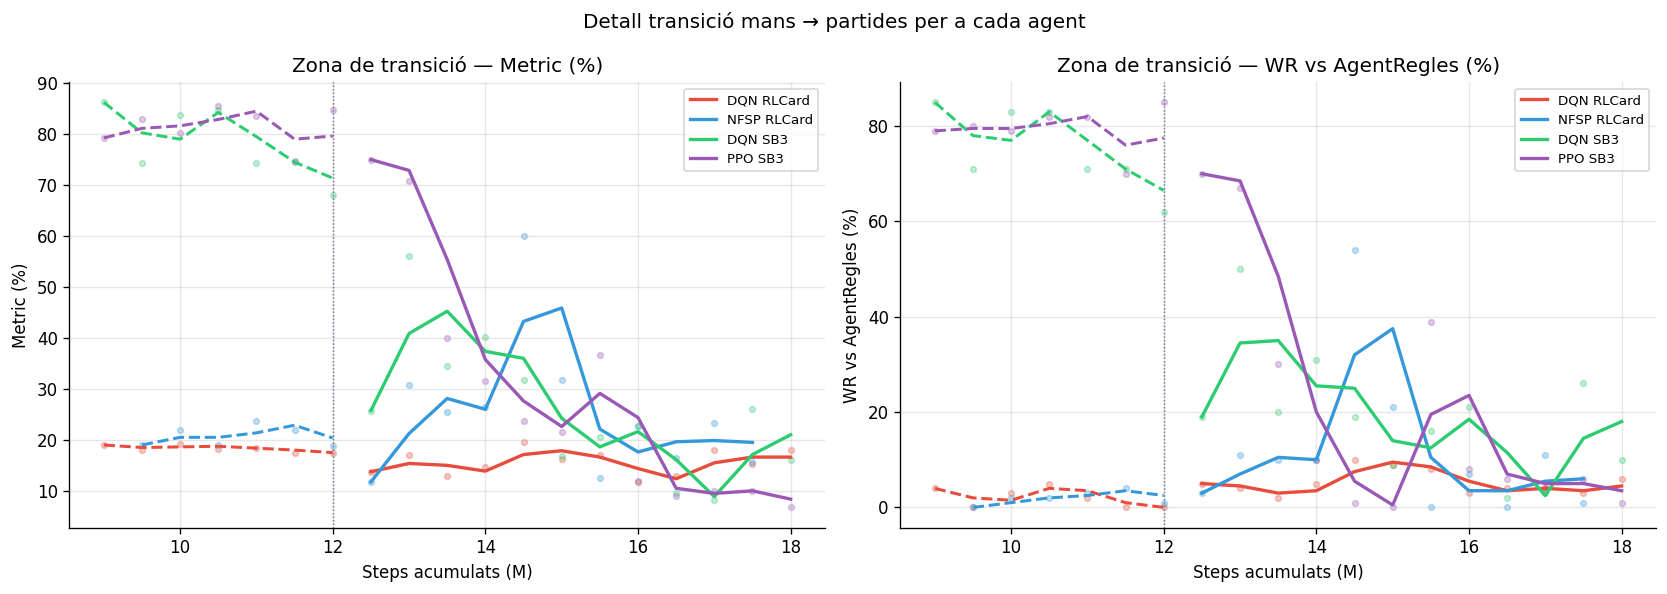

In [10]:
if dades_mans and dades_partides:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Detall transició mans → partides per a cada agent', fontsize=12)

    for ax, col_y, titol in zip(axes,
                                ['eval_metric', 'eval_wr_regles'],
                                ['Metric (%)', 'WR vs AgentRegles (%)']):
        for agent in AGENTS:
            col = COLORS[agent]
            dm  = dades_mans.get(agent)
            dp  = dades_partides.get(agent)

            if dm is None or dp is None:
                continue

            mans_max = dm['step'].max()
            # Últims 3M de mans + primers 6M de partides (zona de transició)
            dm_tail = dm[dm['step'] >= mans_max * 0.75]
            dp_head = dp[dp['step'] <= dp['step'].max() * 0.5]

            s_tail = dm_tail['step'] / 1e6
            s_head = dp_head['step'] / 1e6 + mans_max / 1e6

            ax.scatter(s_tail, dm_tail[col_y], color=col, alpha=0.3, s=12)
            ax.plot(s_tail, suavitzar(dm_tail[col_y], 2), color=col,
                    linestyle='--', linewidth=1.8)
            ax.scatter(s_head, dp_head[col_y], color=col, alpha=0.3, s=12)
            ax.plot(s_head, suavitzar(dp_head[col_y], 2), color=col,
                    linestyle='-', linewidth=2.0, label=LABELS[agent])

            ax.axvline(mans_max / 1e6, color=col, linestyle=':', linewidth=0.8, alpha=0.5)

        ax.set_xlabel('Steps acumulats (M)')
        ax.set_ylabel(titol)
        ax.set_title(f'Zona de transició — {titol}')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('Sense dades de curriculum per a l\'anàlisi de transició.')


---

## 7. Conclusions

### 7.1 Resum quantitatiu

**Taula A — Comparació a 12M steps (mateix pressupost, des de zero, avaluació sobre partides):**

| Agent | Control 12M partides | Curriculum 12M mans | Δ (mans − ctrl) |
|---|---:|---:|---:|
| **DQN RLCard** | 18.2% | 26.0% | **+7.8 pp** ✓ |
| **NFSP RLCard** | 25.2% | 27.2% | +2.0 pp ✓ |
| **DQN SB3** | 44.0% | 86.2% | **+42.2 pp** ✓✓ |
| **PPO SB3** | 30.8% | 87.2% | **+56.5 pp** ✓✓ |

**Taula B — Comparació a 24M steps totals (control sencer vs curriculum complet mans+finetune):**

| Agent | Control 24M partides | Curriculum 12M mans → 12M partides | Δ |
|---|---:|---:|---:|
| **DQN RLCard** | 52.0% | 22.2% | **−29.8 pp** ❌ |
| **NFSP RLCard** | 55.5% | 60.0% | +4.5 pp ✓ |
| **DQN SB3** | 60.5% | 56.0% | −4.5 pp ≈ |
| **PPO SB3** | 35.0% | 75.0% | **+40.0 pp** ✓✓ |

### 7.2 Lectura conjunta de les dues taules

Les dues taules conten històries complementàries. La **Taula A** diu que entrenar sobre mans és *uniformement* millor que entrenar sobre partides donat el mateix pressupost de 12M steps, amb una diferència brutal per als agents SB3 (+42 i +56 pp). Això és una validació forta del valor instrumental de l'entorn per mans com a **senyal d'aprenentatge**: reward dens + horizon curt = convergència molt més ràpida.

La **Taula B** conta com de bé transfereix aquest aprenentatge a l'objectiu real (partides senceres). Aquí la història és molt més barrejada: només 2 de 4 agents milloren, 1 és neutre i 1 col·lapsa. La diferència entre les dues taules és precisament **el problema de la transferència**: aprendre mans molt bé (86–87%) no garanteix conservar el coneixement durant el finetune sobre partides.

### 7.3 Interpretació per agent

**PPO-SB3 — el gran guanyador (+40 pp final, +56.5 pp a 12M).**
A la Fase 1 PPO era l'agent més feble en partides senceres (35%) i al control de Fase 2 torna a estancar-se al 35%. Entrenat sobre mans arriba al **87.2%** (per davant de tots els altres) i el *finetune* sobre partides conserva **75%**. El curriculum **desbloqueja** PPO: valida empíricament que el problema no era l'algorisme sinó l'horizon llarg i el *credit assignment* amb reward sparse. Amb episodis curts (una mà, ~15 steps) i reward dens (`pts/24`), l'on-policy té prou senyal per aprendre polítiques fortes abans de ser exposat a la variància de la partida sencera. La pèrdua de 12 pp en el finetune (87 → 75) és el cost del *shift* de distribució, però el balanç net és enormement positiu.

**DQN-SB3 — aprèn excel·lentment en mans però perd en el finetune (+42.2 pp a 12M, −4.5 pp final).**
És el cas més il·lustratiu del *trade-off* transferència-aprenentatge. Arriba al **86.2%** sobre mans (gairebé empatat amb PPO) però durant els 12M de finetune cau fins al 56%. Si només es disposés de 12M steps, el curriculum seria una **victòria massiva** per DQN-SB3. Amb 24M, el control recupera terreny perquè té més temps per adaptar-se a la distribució de partida sencera. Amb `exploration_rate = 0.10` al finetune i warmup curt, el replay buffer del finetune s'omple amb trajectòries de partida però la Q-function arrossega biaixos apresos sobre mans. Una solució hipotètica: allargar el finetune a 18–24M partides addicionals (pressupost total > control) per comprovar si la política transferida acaba superant el control.

**NFSP-RLCard — benefici modest i estable (+4.5 pp final, +2.0 pp a 12M).**
Encara que aprèn poc en mans (27.2%), la combinació best-response + average policy i la regularització del reservoir buffer absorbeix bé la transició. El pic a partides (60.0%) supera el control. NFSP és l'agent **menys afectat per dinàmiques de distribució** perquè la política mitjana suavitza els shifts. La poca millora a 12M (+2 pp) suggereix que NFSP no explota el reward dens de les mans com ho fan els SB3 — possiblement per la barreja interna RL/SL que diliueix el senyal.

**DQN-RLCard — millora a 12M però col·lapse al finetune (+7.8 pp a 12M, −29.8 pp final).**
L'única configuració on el curriculum **empitjora clarament** el resultat final. Sobre mans a penes aprèn (26.0%, pitjor que DQN-SB3 per ~60 pp) però encara així supera el seu propi control a 12M. El problema ve al finetune: col·lapsa a 22.2% i no es recupera. Dues causes probables combinades:
1. La implementació DQN de RLCard no integra bé el reset del replay buffer i la càrrega de pesos previs.
2. Sense self-play Polyak (que sí tenia a Fase 1), el DQN-RLCard perd el mecanisme de regularització implícita que l'estabilitzava.

### 7.4 Respostes a les preguntes experimentals

1. **El curriculum learning millora el rendiment final?**
   **Sí, condicionat a l'agent i al pressupost.** Si es mira la fase 1 aïllada (12M steps), **tots 4 agents milloren** entrenant sobre mans (Taula A). Si es mira el resultat final després del finetune (24M), només 2 de 4 en surten beneficiats (PPO massivament, NFSP lleugerament). El **coll d'ampolla és la transferència**, no l'aprenentatge inicial.

2. **Quins agents es beneficien més?**
   **Els on-policy** (PPO). L'expectativa inicial era la contrària — es temia l'oblit catastròfic de PPO — però el resultat és l'invers: PPO és precisament qui més necessita un reward dens per arrencar. Els off-policy amb replay buffers grans gestionen millor el reward sparse i tenen menys marge de millora.

3. **Hi ha oblit catastròfic?**
   - **PPO-SB3**: **no significatiu**. La transició 12M→24M és suau; només perd 12 pp de 87 a 75.
   - **DQN-SB3**: **moderat**. Cau de 86% a ~55% durant el finetune. El sostre final és comparable al control, així que no és regressiu en pràctica — però deixa 30 pp sobre la taula.
   - **DQN-RLCard**: **sever**. Col·lapse persistent sense recuperació.
   - **NFSP-RLCard**: **no detectat**. El promig de polítiques amorteix les transicions.

4. **Recomanacions per a treballs posteriors:**
   - **PPO amb curriculum és el nou baseline** del projecte (75% contra `AgentRegles`, el millor de tot el TFG). Cal investigar si amb 3+ etapes (mans → mans+envit → partides) puja encara més.
   - **DQN-SB3 val la pena re-estudiar-lo** amb un finetune més llarg o un learning rate reduït: té un 86.2% desaprofitat que seria una llàstima no intentar conservar.
   - **DQN-RLCard s'ha de descartar** d'aquest tipus d'experiment fins que s'estabilitzi la seva integració amb la càrrega de pesos externs.
   - **L'eficàcia del curriculum depèn crucialment de dues condicions**: (a) que l'etapa 1 aprengui bé les mans (els SB3 sí, els RLCard no) i (b) que la transició preservi la política (PPO sí, DQN no sempre).

### 7.5 Conclusió global

> **La hipòtesi central de la Fase 2 queda validada empíricament**: reformular el problema d'un horizon llarg amb reward sparse a un curriculum de dues etapes **trenca el sostre estructural** de la Fase 1. La prova més forta és doble:
>
> 1. **A igualtat de pressupost (12M steps), entrenar sobre mans és uniformement superior a entrenar sobre partides per als 4 agents**, amb diferències de fins a +56 pp per PPO-SB3. Això vol dir que l'entorn `TrucEnvMa` proporciona un senyal d'aprenentatge qualitativament millor.
>
> 2. **PPO-SB3 passa de 35% a 75%** amb el curriculum complet: +40 pp en el pressupost total, convertint l'agent més feble de Fase 1 en el millor del projecte.
>
> Tanmateix, el benefici final no és universal ni automàtic: la transferència del coneixement de mans a partides és el veritable coll d'ampolla i depèn tant de l'algorisme com de la qualitat de la implementació. La lliçó metodològica és que *curriculum learning* ha de ser tractat com una hipòtesi experimental per validar cas a cas, no com un mecanisme genèricament beneficiós — però quan funciona, funciona espectacularment.
